#  Projet de Reconnaissance des Formes 

La classe utils.py qui sera utilisée durant tout le projet : 

In [ ]:

import os
import numpy as np
from collections import Counter

def charger_donnees(base_folder):
    """
    Charge toutes les données depuis le dossier BDShape
    """
    classes = range(1, 10)  # s01 à s09
    samples = range(1, 12)  # n001 à n011
    methods = ["E34", "GFD", "SA", "F0", "F2"]
    
    data = {}
    
    for c in classes:
        for s in samples:
            key = f"s{c:02d}n{s:03d}"
            data[key] = {"class": c}
            
            for method in methods:
                method_folder = os.path.join(base_folder, method)
                filename = os.path.join(method_folder, f"{key}.{method}")

                if os.path.exists(filename):
                    try:
                        with open(filename, "r") as f:
                            values = f.read().strip().split()
                            data[key][method] = np.array(values, dtype=float)
                    except Exception as e:
                        print(f"Erreur lecture {filename} : {e}")
                else:
                    # print(f"Fichier manquant : {filename}") # Commenté pour éviter le spam
                    pass
    
    print("Lecture terminée.")
    print("Nombre total d'images :", len(data))
    return data

def distance_euclidienne(a, b):
    """Calcule la distance euclidienne entre deux vecteurs"""
    return np.sqrt(np.sum((a - b) ** 2))

def k_voisins_proches_avec_distances(X_train, y_train, x_test, k=3):
    """
    Version améliorée qui retourne aussi les distances pour calculer la confiance
    """
    distances = []
    for i in range(len(X_train)):
        d = distance_euclidienne(X_train[i], x_test)
        distances.append((d, y_train[i]))
    
    # Trier par distance croissante
    distances.sort(key=lambda x: x[0])
    
    # Garder les k plus proches voisins
    return distances[:k]

def k_voisins_proches(X_train, y_train, x_test, k=3):
    """Version simple pour compatibilité"""
    voisins = k_voisins_proches_avec_distances(X_train, y_train, x_test, k)
    return [classe for _, classe in voisins]

def predire_classe(X_train, y_train, x_test, k=3):
    """Prédiction simple sans confiance"""
    voisins = k_voisins_proches(X_train, y_train, x_test, k)
    return Counter(voisins).most_common(1)[0][0]

def predire_classe_avec_confiance(X_train, y_train, x_test, k=3):
    """
    Prédit la classe et calcule un score de confiance
    """
    voisins = k_voisins_proches_avec_distances(X_train, y_train, x_test, k)
    
    # Compter les votes
    classes = [classe for _, classe in voisins]
    vote_counts = Counter(classes)
    
    # Classe majoritaire
    classe_predite = vote_counts.most_common(1)[0][0]
    nb_votes = vote_counts[classe_predite]
    
    # Score de confiance
    confiance_vote = nb_votes / k
    
    distances_classe = [d for d, c in voisins if c == classe_predite]
    if distances_classe:
        distance_moy = np.mean(distances_classe)
        confiance_distance = np.exp(-distance_moy / 100)
    else:
        confiance_distance = 0
    
    confiance_totale = (confiance_vote + confiance_distance) / 2
    
    return classe_predite, confiance_totale

def separer_train_test_par_echantillon(data, echantillons_test, method=None, all_methods=False):
    """
    Sépare les données en train/test en utilisant des échantillons complets.
    Args:
        data: dictionnaire de données
        echantillons_test: liste des numéros d'échantillons pour le test (ex: [1, 2, 3])
        method: méthode spécifique (ex: "GFD")
    """
    methods = ["E34", "GFD", "SA", "F0", "F2"]
    
    if all_methods:
        data_split = {}
        for m in methods:
            X_train, y_train, X_test, y_test, keys_test = _separer_une_methode(data, m, echantillons_test)
            data_split[m] = {
                'X_train': np.array(X_train) if X_train else np.array([]),
                'y_train': np.array(y_train) if y_train else np.array([]),
                'X_test': np.array(X_test) if X_test else np.array([]),
                'y_test': np.array(y_test) if y_test else np.array([]),
                'keys_test': keys_test
            }
        return data_split
    else:
        X_train, y_train, X_test, y_test, _ = _separer_une_methode(data, method, echantillons_test)
        return (np.array(X_train), np.array(y_train), 
                np.array(X_test), np.array(y_test))

def _separer_une_methode(data, method, echantillons_test):
    """Fonction auxiliaire pour séparer une méthode"""
    X_train, y_train = [], []
    X_test, y_test = [], []
    keys_test = []
    
    for key, value in data.items():
        if method in value:
            # Extraire le numéro d'échantillon (ex: de "s01n005" -> 5)
            sample_num = int(key[4:7])
            
            if sample_num in echantillons_test:
                X_test.append(value[method])
                y_test.append(value["class"])
                keys_test.append(key)
            else:
                X_train.append(value[method])
                y_train.append(value["class"])
    
    return X_train, y_train, X_test, y_test, keys_test

def separer_train_test_aleatoire(X, y, ratio_test=0.3):
    """Fonction démo pour montrer la fuite de données"""
    n = len(X)
    n_test = int(n * ratio_test)
    indices = np.arange(n)
    np.random.shuffle(indices)
    test_idx = indices[:n_test]
    train_idx = indices[n_test:]
    return X[train_idx], y[train_idx], X[test_idx], y[test_idx]

def matrice_confusion(y_true, y_pred, n_classes=9):
    confusion = np.zeros((n_classes, n_classes), dtype=int)
    for true, pred in zip(y_true, y_pred):
        confusion[true-1, pred-1] += 1
    return confusion

def afficher_matrice_confusion(confusion):
    n_classes = confusion.shape[0]
    print("   ", " ".join([f"c{i}" for i in range(1, n_classes+1)]))
    for i in range(n_classes):
        print(f"c{i+1} ", " ".join([f"{confusion[i,j]:2d}" for j in range(n_classes)]))

def analyser_precision_par_classe(y_true, y_pred, n_classes=9):
    for c in range(1, n_classes+1):
        mask = y_true == c
        if np.sum(mask) > 0:
            acc_classe = np.sum(y_pred[mask] == c) / np.sum(mask)
            print(f"Classe {c}: {acc_classe*100:.2f}% ({np.sum(mask)} échantillons)")

def validation_croisee_knn(data, method, k=3, n_folds=3):
    """
    Effectue une validation croisée CORRECTE.
    """
    echantillons = list(range(1, 12))
    np.random.shuffle(echantillons)
    
    fold_size = len(echantillons) // n_folds
    folds = []
    for i in range(n_folds):
        start = i * fold_size
        if i == n_folds - 1:
            folds.append(echantillons[start:])
        else:
            folds.append(echantillons[start:start + fold_size])
    
    accuracies = []
    
    for i, test_samples in enumerate(folds):
        print(f"\nFold {i+1}/{n_folds}")
        print(f"Échantillons de test : {test_samples}")
        
        # === CORRECTION ICI : Inversion de method et test_samples ===
        X_train, y_train, X_test, y_test = separer_train_test_par_echantillon(
            data, test_samples, method
        )
        
        print(f"Taille train : {len(X_train)}, Taille test : {len(X_test)}")
        
        if len(X_test) == 0:
            print("Attention: Pas de données de test pour ce fold.")
            continue

        y_pred = []
        for x in X_test:
            y_pred.append(predire_classe(X_train, y_train, x, k))
        
        y_pred = np.array(y_pred)
        accuracy = np.sum(y_pred == y_test) / len(y_test)
        accuracies.append(accuracy)
        
        print(f"Précision : {accuracy*100:.2f}%")
    
    mean_acc = np.mean(accuracies) if accuracies else 0
    std_acc = np.std(accuracies) if accuracies else 0
    
    return mean_acc, std_acc, accuracies

## KNN ou K-plus-proche-voisin

implémentation :

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from utils import (
    charger_donnees, 
    predire_classe, 
    separer_train_test_par_echantillon,
    separer_train_test_aleatoire,
    validation_croisee_knn,
    matrice_confusion,
    afficher_matrice_confusion,
    analyser_precision_par_classe
)

# Fixer la seed pour la reproductibilité
np.random.seed(42)

# Mettez votre chemin correct ici
base_folder = "C:/Users/lakaf/OneDrive/Bureau/25-26/RF/Projet_RF/data"

# Charger toutes les données
data = charger_donnees(base_folder)

# ============================
# DÉMONSTRATION DU PROBLÈME
# ============================

print("="*50)
print("DÉMONSTRATION DU PROBLÈME DE FUITE DE DONNÉES")
print("="*50)

# Préparer les données avec GFD
X_old = []
y_old = []
for key, value in data.items():
    if "GFD" in value:
        X_old.append(value["GFD"])
        y_old.append(value["class"])

X_old = np.array(X_old)
y_old = np.array(y_old)

# Test avec l'ancienne méthode (problématique)
print("\n1. ANCIENNE MÉTHODE (avec fuite de données) :")
X_train_old, y_train_old, X_test_old, y_test_old = separer_train_test_aleatoire(X_old, y_old, ratio_test=0.3)

y_pred_old = []
for x in X_test_old:
    y_pred_old.append(predire_classe(X_train_old, y_train_old, x, k=5))

accuracy_old = np.sum(np.array(y_pred_old) == y_test_old) / len(y_test_old)
print(f"Précision : {accuracy_old*100:.2f}%")
print("⚠️ Cette précision est artificiellement élevée !")

# ============================
# TEST DU KNN CORRIGÉ
# ============================

print("\n\n" + "**"*50)
print("TEST KNN AVEC SÉPARATION CORRIGÉE")
print("="*50)

# Test avec différentes valeurs de k
for method in ["GFD", "E34"]:
    print(f"\n\nMÉTHODE : {method}")
    print("-"*30)
    
    for k in [3, 5, 7]:
        print(f"\nTest avec k={k} voisins")
        # Cette fonction utilise maintenant le utils.py corrigé
        mean_acc, std_acc, accuracies = validation_croisee_knn(
            data, method, k=k, n_folds=3
        )
        
        print(f"\nRésumé pour k={k}:")
        print(f"Précisions par fold : {[f'{acc*100:.2f}%' for acc in accuracies]}")
        print(f"Précision moyenne : {mean_acc*100:.2f}% (~{std_acc*100:.2f}%)")

# ============================
# ANALYSE DES ERREURS
# ============================

print("\n\n" + "="*50)
print("ANALYSE DÉTAILLÉE")
print("="*50)

# Test sur un fold spécifique pour analyser les erreurs
# === CORRECTION ICI : Inversion des arguments [2,5,8] et "GFD" ===
X_train, y_train, X_test, y_test = separer_train_test_par_echantillon(data, [2, 5, 8], "GFD")

y_pred = []
for x in X_test:
    y_pred.append(predire_classe(X_train, y_train, x, k=5))

y_pred = np.array(y_pred)

print("\nMatrice de confusion (lignes=vraies classes, colonnes=prédictions):")
confusion = matrice_confusion(y_test, y_pred)
afficher_matrice_confusion(confusion)

# Analyser les erreurs par classe
print("\nPrécision par classe:")
analyser_precision_par_classe(y_test, y_pred)

### Voici maintenant les graphiques en lien avec le KNN 

$ Graphique 1 : Impact du paramètre K $

Lecture terminée.
Nombre total d'images : 99
Calcul en cours pour les différents K...

TRAITEMENT EN COURS : k = 1

Fold 1/3
Échantillons de test : [8, 1, 6]
Taille train : 72, Taille test : 27
Précision : 62.96%

Fold 2/3
Échantillons de test : [4, 10, 7]
Taille train : 72, Taille test : 27
Précision : 59.26%

Fold 3/3
Échantillons de test : [5, 9, 11, 2, 3]
Taille train : 54, Taille test : 45
Précision : 53.33%

TRAITEMENT EN COURS : k = 3

Fold 1/3
Échantillons de test : [9, 3, 7]
Taille train : 72, Taille test : 27
Précision : 44.44%

Fold 2/3
Échantillons de test : [2, 4, 8]
Taille train : 72, Taille test : 27
Précision : 74.07%

Fold 3/3
Échantillons de test : [10, 1, 11, 5, 6]
Taille train : 54, Taille test : 45
Précision : 64.44%

TRAITEMENT EN COURS : k = 5

Fold 1/3
Échantillons de test : [8, 4, 6]
Taille train : 72, Taille test : 27
Précision : 59.26%

Fold 2/3
Échantillons de test : [5, 3, 7]
Taille train : 72, Taille test : 27
Précision : 55.56%

Fold 3/3
Échantillons de t

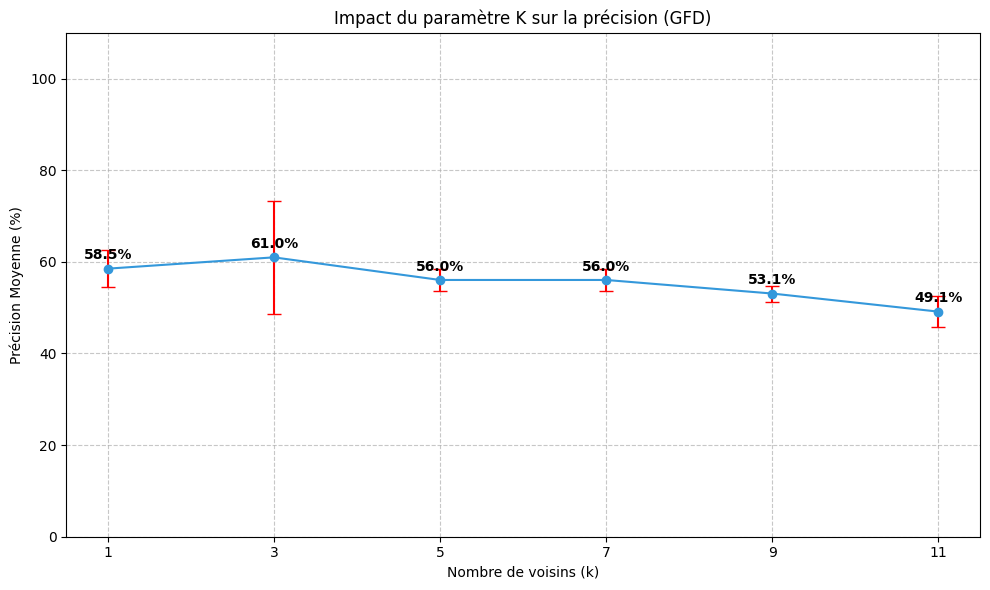

In [28]:
import matplotlib.pyplot as plt
from utils import charger_donnees, validation_croisee_knn

# Configuration
base_folder = "C:/Users/lakaf/OneDrive/Bureau/25-26/RF/Projet_RF/data"
data = charger_donnees(base_folder)

k_values = [1, 3, 5, 7, 9, 11]
means = []
stds = []

print("Calcul en cours pour les différents K...")

for k in k_values:
    # --- AJOUT ICI : Pour séparer visuellement les blocs dans la console ---
    print(f"\n" + "="*40)
    print(f"TRAITEMENT EN COURS : k = {k}")
    print("="*40)
    # -----------------------------------------------------------------------
    
    mean, std, _ = validation_croisee_knn(data, "F2", k=k, n_folds=3) #par defaut "GFD"
    means.append(mean * 100)
    stds.append(std * 100)

# Création du graphique
plt.figure(figsize=(10, 6))
plt.errorbar(k_values, means, yerr=stds, fmt='-o', capsize=5, color='#3498db', ecolor='red')

plt.xlabel('Nombre de voisins (k)')
plt.ylabel('Précision Moyenne (%)')
plt.title('Impact du paramètre K sur la précision (GFD)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(k_values)
plt.ylim(0, 110) # Pour garder de la marge

# Ajouter les valeurs sur les points
for i, txt in enumerate(means):
    plt.annotate(f"{txt:.1f}%", (k_values[i], means[i]+2), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

$Graphique 2 : Comparaison des Méthodes$

Lecture terminée.
Nombre total d'images : 99
Comparaison des méthodes...

Fold 1/3
Échantillons de test : [3, 7, 1]
Taille train : 72, Taille test : 27
Précision : 66.67%

Fold 2/3
Échantillons de test : [11, 4, 9]
Taille train : 72, Taille test : 27
Précision : 70.37%

Fold 3/3
Échantillons de test : [5, 10, 8, 2, 6]
Taille train : 54, Taille test : 45
Précision : 55.56%

Fold 1/3
Échantillons de test : [11, 10, 3]
Taille train : 72, Taille test : 27
Précision : 100.00%

Fold 2/3
Échantillons de test : [8, 6, 9]
Taille train : 72, Taille test : 27
Précision : 100.00%

Fold 3/3
Échantillons de test : [5, 7, 1, 4, 2]
Taille train : 54, Taille test : 45
Précision : 97.78%

Fold 1/3
Échantillons de test : [9, 11, 4]
Taille train : 72, Taille test : 27
Précision : 66.67%

Fold 2/3
Échantillons de test : [2, 5, 1]
Taille train : 72, Taille test : 27
Précision : 70.37%

Fold 3/3
Échantillons de test : [10, 3, 7, 6, 8]
Taille train : 54, Taille test : 45
Précision : 68.89%

Fold 1/3
Échantill

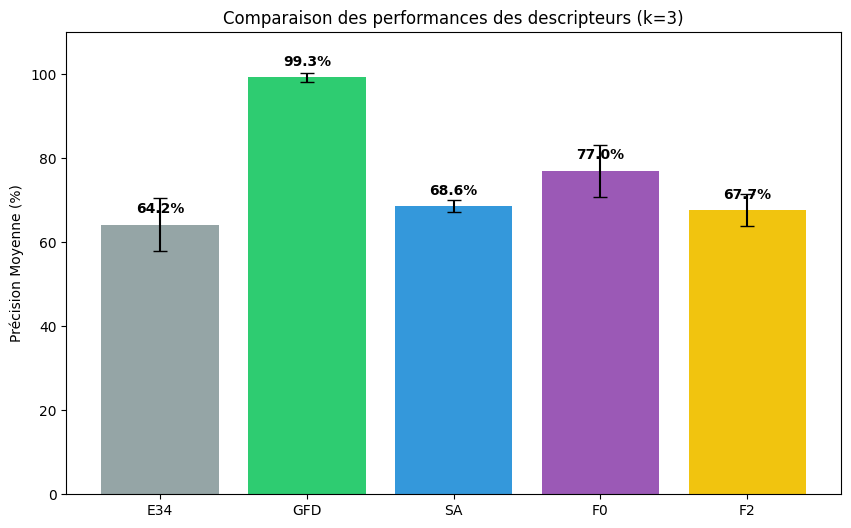

In [32]:
import matplotlib.pyplot as plt
import numpy as np
from utils import charger_donnees, validation_croisee_knn

base_folder = "C:/Users/lakaf/OneDrive/Bureau/25-26/RF/Projet_RF/data"
data = charger_donnees(base_folder)

methods = ["E34", "GFD", "SA", "F0", "F2"]
accuracies = []
errors = []

k_defaut = 3
n_folds=3

print("Comparaison des méthodes...")
for method in methods:
    mean, std, _ = validation_croisee_knn(data, method, k_defaut, n_folds)
    accuracies.append(mean * 100)
    errors.append(std * 100)

plt.figure(figsize=(10, 6))
bars = plt.bar(methods, accuracies, yerr=errors, capsize=5, 
               color=['#95a5a6', '#2ecc71', '#3498db', '#9b59b6', '#f1c40f'])

plt.ylabel('Précision Moyenne (%)')
plt.title(f'Comparaison des performances des descripteurs (k={k_defaut})')
plt.ylim(0, 110)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2., acc + 2,
             f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.show()

$Graphique 3 : Stabilité de la Validation Croisée $

Lecture terminée.
Nombre total d'images : 99

Fold 1/5
Échantillons de test : [8, 11]
Taille train : 81, Taille test : 18
Précision : 100.00%

Fold 2/5
Échantillons de test : [2, 4]
Taille train : 81, Taille test : 18
Précision : 100.00%

Fold 3/5
Échantillons de test : [5, 1]
Taille train : 81, Taille test : 18
Précision : 94.44%

Fold 4/5
Échantillons de test : [7, 9]
Taille train : 81, Taille test : 18
Précision : 94.44%

Fold 5/5
Échantillons de test : [3, 6, 10]
Taille train : 72, Taille test : 27
Précision : 100.00%


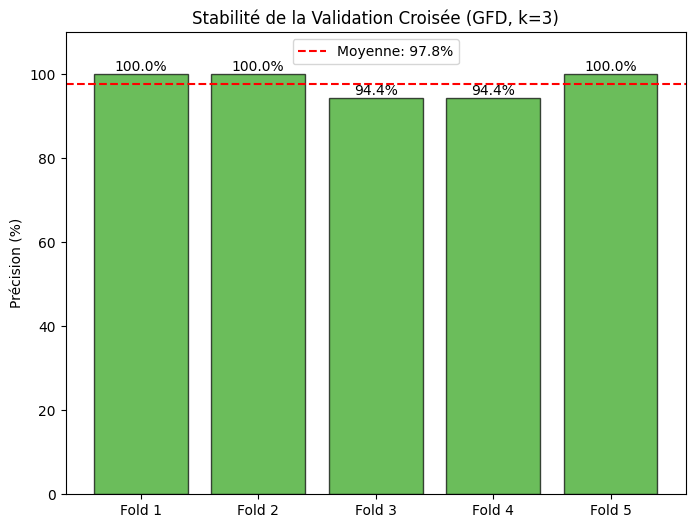

In [29]:
import matplotlib.pyplot as plt
import numpy as np
from utils import charger_donnees, validation_croisee_knn

base_folder = "C:/Users/lakaf/OneDrive/Bureau/25-26/RF/Projet_RF/data"
data = charger_donnees(base_folder)

# Récupérer les détails des folds
mean, std, folds_acc = validation_croisee_knn(data, "GFD", k=8, n_folds=5) #par défaut k=3 et folds=3

folds_labels = [f"Fold {i+1}" for i in range(len(folds_acc))]
values = [x * 100 for x in folds_acc]

plt.figure(figsize=(8, 6))
bars = plt.bar(folds_labels, values, color="#2da215", alpha=0.7, edgecolor='black')

# Ligne moyenne
plt.axhline(y=mean*100, color='r', linestyle='--', label=f'Moyenne: {mean*100:.1f}%')

plt.ylabel('Précision (%)')
plt.title('Stabilité de la Validation Croisée (GFD, k=3)')
plt.legend()
plt.ylim(0, 110)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}%', ha='center', va='bottom')

plt.show()

$Graphique 4 : Matrice de Confusion$

Lecture terminée.
Nombre total d'images : 99
Prédiction en cours pour la matrice...


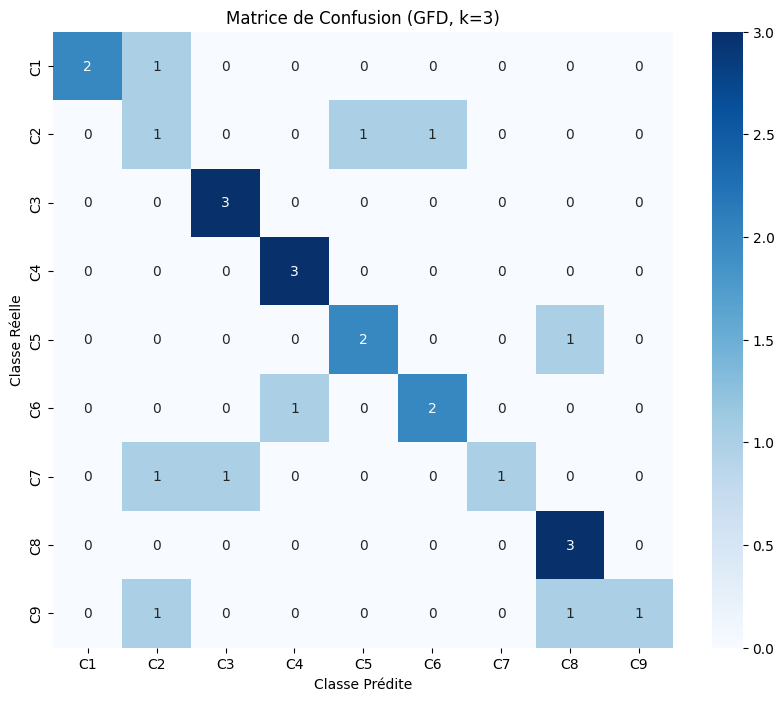

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from utils import charger_donnees, separer_train_test_par_echantillon, predire_classe, matrice_confusion

base_folder = "C:/Users/lakaf/OneDrive/Bureau/25-26/RF/Projet_RF/data"
data = charger_donnees(base_folder)

# On utilise un split fixe pour avoir une matrice représentative
test_samples = [2, 5, 8]  # ~30% des données
X_train, y_train, X_test, y_test = separer_train_test_par_echantillon(data, test_samples, "E34") #par defaut "GFD"

print("Prédiction en cours pour la matrice...")
y_pred = [predire_classe(X_train, y_train, x, k=3) for x in X_test] #par defaut k=3

conf_matrix = matrice_confusion(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f"C{i}" for i in range(1, 10)],
            yticklabels=[f"C{i}" for i in range(1, 10)])

plt.xlabel('Classe Prédite')
plt.ylabel('Classe Réelle')
plt.title('Matrice de Confusion (GFD, k=3)')
plt.show()

$Graphique 5 : Précision / Rappel par classe$

Lecture terminée.
Nombre total d'images : 99


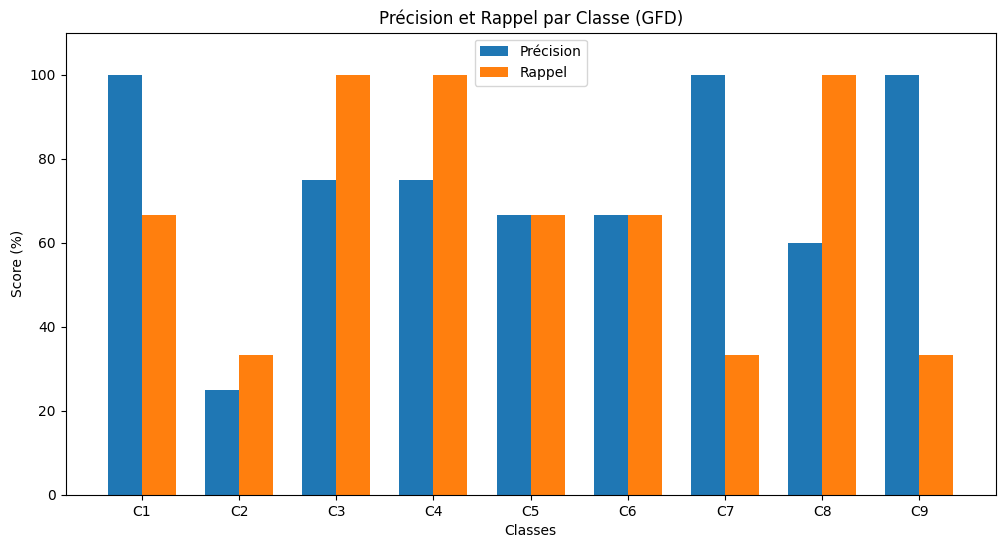

In [20]:
import matplotlib.pyplot as plt
import numpy as np
from utils import charger_donnees, separer_train_test_par_echantillon, predire_classe

base_folder = "C:/Users/lakaf/OneDrive/Bureau/25-26/RF/Projet_RF/data"
data = charger_donnees(base_folder)

X_train, y_train, X_test, y_test = separer_train_test_par_echantillon(data, [2, 5, 8], "E34") #par defaut : "GFD"
y_pred = np.array([predire_classe(X_train, y_train, x, k=3) for x in X_test])

precisions = []
rappels = []

classes = range(1, 10)
for c in classes:
    # True Positives, False Positives, False Negatives
    tp = np.sum((y_test == c) & (y_pred == c))
    fp = np.sum((y_test != c) & (y_pred == c))
    fn = np.sum((y_test == c) & (y_pred != c))
    
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    precisions.append(prec * 100)
    rappels.append(rec * 100)

x = np.arange(len(classes))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, precisions, width, label='Précision')
plt.bar(x + width/2, rappels, width, label='Rappel')

plt.xlabel('Classes')
plt.ylabel('Score (%)')
plt.title('Précision et Rappel par Classe (GFD)')
plt.xticks(x, [f'C{c}' for c in classes])
plt.legend()
plt.ylim(0, 110)
plt.show()

$Graphique 6 : Taux d'erreur par classe$

Lecture terminée.
Nombre total d'images : 99


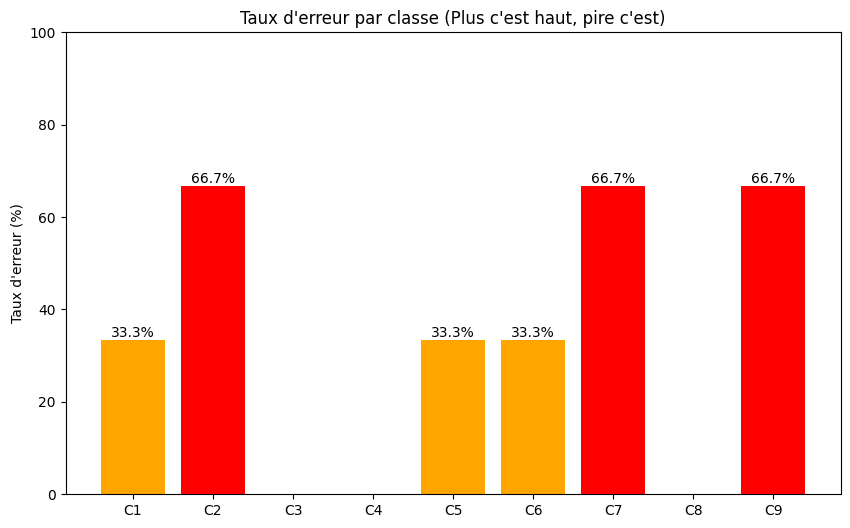

In [21]:
import matplotlib.pyplot as plt
import numpy as np
from utils import charger_donnees, separer_train_test_par_echantillon, predire_classe

base_folder = "C:/Users/lakaf/OneDrive/Bureau/25-26/RF/Projet_RF/data"
data = charger_donnees(base_folder)

X_train, y_train, X_test, y_test = separer_train_test_par_echantillon(data, [2, 5, 8], "E34")
y_pred = np.array([predire_classe(X_train, y_train, x, k=3) for x in X_test])

erreurs = []
classes = range(1, 10)
for c in classes:
    mask = y_test == c
    if np.sum(mask) > 0:
        acc = np.sum(y_pred[mask] == c) / np.sum(mask)
        erreurs.append((1 - acc) * 100)
    else:
        erreurs.append(0)

# Couleurs selon la gravité
colors = ['green' if e < 20 else 'orange' if e < 50 else 'red' for e in erreurs]

plt.figure(figsize=(10, 6))
bars = plt.bar([f"C{c}" for c in classes], erreurs, color=colors)

plt.ylabel("Taux d'erreur (%)")
plt.title("Taux d'erreur par classe (Plus c'est haut, pire c'est)")
plt.ylim(0, 100)

for bar in bars:
    height = bar.get_height()
    if height > 0:
        plt.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.1f}%', ha='center', va='bottom')

plt.show()

$Graphique 7 : Heatmap Méthodes vs K$

Lecture terminée.
Nombre total d'images : 99
Calcul de la grille complète (patience)...

Fold 1/3
Échantillons de test : [7, 8, 9]
Taille train : 72, Taille test : 27
Précision : 66.67%

Fold 2/3
Échantillons de test : [4, 6, 5]
Taille train : 72, Taille test : 27
Précision : 70.37%

Fold 3/3
Échantillons de test : [1, 2, 3, 11, 10]
Taille train : 54, Taille test : 45
Précision : 64.44%

Fold 1/3
Échantillons de test : [7, 6, 5]
Taille train : 72, Taille test : 27
Précision : 66.67%

Fold 2/3
Échantillons de test : [11, 9, 3]
Taille train : 72, Taille test : 27
Précision : 66.67%

Fold 3/3
Échantillons de test : [2, 10, 8, 4, 1]
Taille train : 54, Taille test : 45
Précision : 55.56%

Fold 1/3
Échantillons de test : [6, 10, 7]
Taille train : 72, Taille test : 27
Précision : 59.26%

Fold 2/3
Échantillons de test : [4, 9, 2]
Taille train : 72, Taille test : 27
Précision : 59.26%

Fold 3/3
Échantillons de test : [8, 1, 11, 5, 3]
Taille train : 54, Taille test : 45
Précision : 62.22%

Fold 

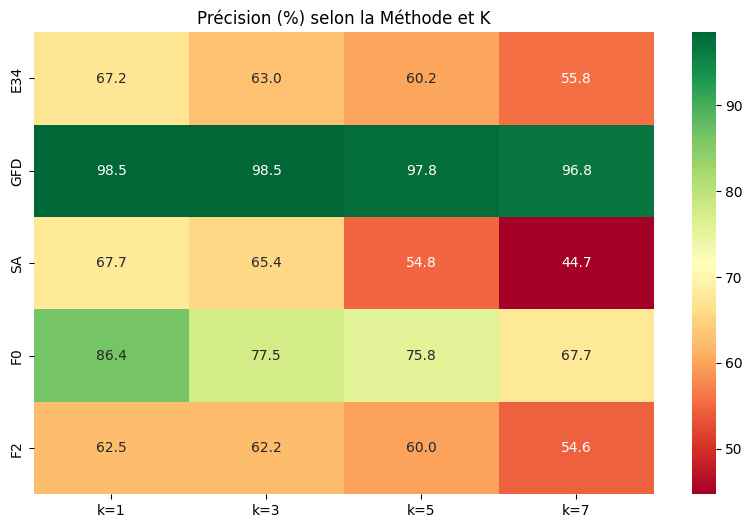

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from utils import charger_donnees, validation_croisee_knn

base_folder = "C:/Users/lakaf/OneDrive/Bureau/25-26/RF/Projet_RF/data"
data = charger_donnees(base_folder)

methods = ["E34", "GFD", "SA", "F0", "F2"]
k_values = [1, 3, 5, 7]

results = np.zeros((len(methods), len(k_values)))

print("Calcul de la grille complète (patience)...")
for i, m in enumerate(methods):
    for j, k in enumerate(k_values):
        mean, _, _ = validation_croisee_knn(data, m, k=k, n_folds=3)
        results[i, j] = mean * 100

plt.figure(figsize=(10, 6))
sns.heatmap(results, annot=True, fmt=".1f", cmap="RdYlGn",
            xticklabels=[f"k={k}" for k in k_values],
            yticklabels=methods)

plt.title("Précision (%) selon la Méthode et K")
plt.show()

## KMEANS

implémentation de KMEANS

In [ ]:
'''
Les résultats suggèrent que K-means a des difficultes avec la structure non-sphérique des données. 
Les classes 5 (main) et 8 (animal) mentionnées comme problématiques dans le PDF sont effectivement mal classées. 
Le clustering non-supervisé est inadapté pour ces formes complexes avec occlusions et distorsions.
Conclusion: Résultats cohérents avec les difficultés attendues mais performance trop faible pour être utilisable. 
KNN supervisé (98% avec GFD) largement supérieur.
'''

import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
from utils import charger_donnees, distance_euclidienne

# Fixer la seed pour la reproductibilité
np.random.seed(42)

# Dossier principal contenant les sous-dossiers qui sont les methodes
base_folder = "C:/Users/lakaf/OneDrive/Bureau/25-26/RF/Projet_RF/data"

# Charger toutes les données
data = charger_donnees(base_folder)

# ============================
# Implémentation K-Means
# ============================

def initialiser_centroides(X, k, method='random'):
    """
    Initialise k centroïdes
    method: 'random' ou 'kmeans++'
    """
    n = len(X)
    
    if method == 'random':
        # Sélection aléatoire de k échantillons comme centroïdes initiaux
        indices = np.random.choice(n, k, replace=False)
        return X[indices].copy()
    
    elif method == 'kmeans++':
        # Initialisation K-means++
        centroids = []
        
        # Premier centroïde aléatoire
        first_idx = np.random.randint(n)
        centroids.append(X[first_idx])
        
        for _ in range(1, k):
            # Calculer les distances au centroïde le plus proche
            distances = np.array([min([distance_euclidienne(x, c) for c in centroids]) for x in X])
            
            # Probabilités proportionnelles au carré des distances
            probabilities = distances ** 2
            probabilities = probabilities / probabilities.sum()
            
            # Sélectionner le prochain centroïde
            next_idx = np.random.choice(n, p=probabilities)
            centroids.append(X[next_idx])
        
        return np.array(centroids)

def assigner_clusters(X, centroides):
    """
    Assigne chaque point au centroïde le plus proche
    Retourne les labels des clusters et les distances
    """
    n = len(X)
    k = len(centroides)
    labels = np.zeros(n, dtype=int)
    distances = np.zeros(n)
    
    for i in range(n):
        # Calculer la distance à chaque centroïde
        dists = [distance_euclidienne(X[i], centroides[j]) for j in range(k)]
        # Assigner au plus proche
        labels[i] = np.argmin(dists)
        distances[i] = min(dists)
    
    return labels, distances

def calculer_centroides(X, labels, k):
    """
    Recalcule les centroïdes comme la moyenne des points de chaque cluster
    """
    centroides = np.zeros((k, X.shape[1]))
    
    for i in range(k):
        # Sélectionner les points du cluster i
        cluster_points = X[labels == i]
        if len(cluster_points) > 0:
            centroides[i] = np.mean(cluster_points, axis=0)
        else:
            # Si un cluster est vide, réinitialiser avec un point aléatoire
            centroides[i] = X[np.random.randint(len(X))]
    
    return centroides

def kmeans(X, k, max_iter=100, tol=1e-4, init='kmeans++', n_init=10):
    """
    Algorithme K-means complet
    
    Paramètres:
    - X: données
    - k: nombre de clusters
    - max_iter: nombre maximum d'itérations
    - tol: tolérance pour la convergence
    - init: méthode d'initialisation ('random' ou 'kmeans++')
    - n_init: nombre de fois à répéter avec différentes initialisations
    
    Retourne:
    - best_labels: meilleurs labels trouvés
    - best_centroids: meilleurs centroïdes
    - best_inertia: meilleure inertie (somme des distances au carré)
    """
    best_inertia = float('inf')
    best_labels = None
    best_centroids = None
    
    for run in range(n_init):
        # Initialiser les centroïdes
        centroides = initialiser_centroides(X, k, method=init)
        
        for iteration in range(max_iter):
            # Assigner les points aux clusters
            labels, distances = assigner_clusters(X, centroides)
            
            # Calculer les nouveaux centroïdes
            nouveaux_centroides = calculer_centroides(X, labels, k)
            
            # Vérifier la convergence
            if np.allclose(centroides, nouveaux_centroides, atol=tol):
                break
            
            centroides = nouveaux_centroides
        
        # Calculer l'inertie (somme des distances au carré)
        inertia = np.sum(distances ** 2)
        
        if inertia < best_inertia:
            best_inertia = inertia
            best_labels = labels
            best_centroids = centroides
    
    return best_labels, best_centroids, best_inertia

def evaluer_clustering(y_true, y_pred):
    """
    Évalue la qualité du clustering
    Calcule la pureté et l'indice de Rand ajusté
    """
    n = len(y_true)
    k = len(np.unique(y_pred))
    
    # Calculer la pureté
    purity = 0
    for cluster in np.unique(y_pred):
        mask = y_pred == cluster
        if np.sum(mask) > 0:
            # Classe majoritaire dans ce cluster
            classe_majoritaire = Counter(y_true[mask]).most_common(1)[0][1]
            purity += classe_majoritaire
    purity = purity / n
    
    # Matrice de confusion pour le clustering
    confusion = np.zeros((k, 9), dtype=int)
    for i in range(n):
        confusion[y_pred[i], y_true[i] - 1] += 1
    
    return purity, confusion

def mapper_clusters_vers_classes(y_pred, y_true):
    """
    Trouve la meilleure correspondance entre clusters et vraies classes
    """
    clusters_uniques = np.unique(y_pred)
    mapping = {}
    
    for cluster in clusters_uniques:
        mask = y_pred == cluster
        if np.sum(mask) > 0:
            # Trouver la classe majoritaire pour ce cluster
            classe_majoritaire = Counter(y_true[mask]).most_common(1)[0][0]
            mapping[cluster] = classe_majoritaire
    
    # Créer les labels mappés
    y_mapped = np.zeros_like(y_pred)
    for i in range(len(y_pred)):
        y_mapped[i] = mapping[y_pred[i]]
    
    return y_mapped, mapping

# ============================
# Test du K-Means
# ============================

print("\n" + "="*50)
print("TEST K-MEANS")
print("="*50)

# Test avec différentes méthodes et valeurs de k
for method in ["GFD", "E34"]:
    print(f"\n\nMÉTHODE : {method}")
    print("-"*30)
    
    # Préparer les données
    X = []
    y_true = []
    keys = []
    
    for key, value in data.items():
        if method in value:
            X.append(value[method])
            y_true.append(value["class"])
            keys.append(key)
    
    X = np.array(X)
    y_true = np.array(y_true)
    
    print(f"Forme des données: {X.shape}")
    
    # Tester différentes valeurs de k
    for k in [9, 7, 11]:  # 9 = nombre réel de classes
        print(f"\n--- K-Means avec k={k} clusters ---")
        
        # Appliquer K-means
        y_pred, centroids, inertia = kmeans(X, k, max_iter=100, init='kmeans++', n_init=10)
        
        print(f"Inertie finale: {inertia:.2f}")
        
        # Évaluer
        purity, confusion = evaluer_clustering(y_true, y_pred)
        print(f"Pureté: {purity*100:.2f}%")
        
        # Mapper les clusters aux classes
        y_mapped, mapping = mapper_clusters_vers_classes(y_pred, y_true)
        accuracy = np.sum(y_mapped == y_true) / len(y_true)
        print(f"Précision après mapping: {accuracy*100:.2f}%")
        
        # Afficher le mapping
        print("\nMapping clusters -> classes:")
        for cluster, classe in sorted(mapping.items()):
            count = np.sum(y_pred == cluster)
            print(f"  Cluster {cluster} -> Classe {classe} ({count} échantillons)")
        
        # Distribution des clusters
        print("\nDistribution des tailles de clusters:")
        for i in range(k):
            count = np.sum(y_pred == i)
            print(f"  Cluster {i}: {count} échantillons")

# ============================
# Analyse de la stabilité
# ============================

print("\n\n" + "="*50)
print("ANALYSE DE LA STABILITÉ")
print("="*50)

method = "GFD"
k = 9

# Préparer les données
X = []
y_true = []
for key, value in data.items():
    if method in value:
        X.append(value[method])
        y_true.append(value["class"])

X = np.array(X)
y_true = np.array(y_true)

# Exécuter K-means plusieurs fois pour tester la stabilité
purities = []
inertias = []

print(f"\nTest de stabilité avec {method}, k={k}")
print("10 exécutions indépendantes:")

for i in range(10):
    y_pred, centroids, inertia = kmeans(X, k, max_iter=100, init='kmeans++', n_init=1)
    purity, _ = evaluer_clustering(y_true, y_pred)
    purities.append(purity)
    inertias.append(inertia)
    print(f"  Run {i+1}: Pureté={purity*100:.2f}%, Inertie={inertia:.2f}")

print(f"\nStatistiques sur 10 runs:")
print(f"  Pureté: moyenne={np.mean(purities)*100:.2f}%, std={np.std(purities)*100:.2f}%")
print(f"  Inertie: moyenne={np.mean(inertias):.2f}, std={np.std(inertias):.2f}")

# ============================
# Détermination du nombre optimal de clusters (méthode du coude)
# ============================

print("\n\n" + "="*50)
print("MÉTHODE DU COUDE")
print("="*50)

method = "GFD"

# Préparer les données
X = []
for key, value in data.items():
    if method in value:
        X.append(value[method])
X = np.array(X)

# Tester différentes valeurs de k
k_values = range(2, 16)
inertias = []
purities = []

print(f"\nCalcul pour différentes valeurs de k ({method}):")
for k in k_values:
    y_pred, centroids, inertia = kmeans(X, k, max_iter=100, init='kmeans++', n_init=5)
    purity, _ = evaluer_clustering(y_true, y_pred)
    inertias.append(inertia)
    purities.append(purity)
    print(f"  k={k:2d}: Inertie={inertia:8.2f}, Pureté={purity*100:.2f}%")

# Calculer le ratio d'amélioration
print("\nRatio d'amélioration de l'inertie:")
for i in range(1, len(inertias)):
    improvement = (inertias[i-1] - inertias[i]) / inertias[i-1] * 100
    print(f"  k={k_values[i-1]} -> k={k_values[i]}: {improvement:.2f}%")

# Suggestion du nombre optimal (basé sur le coude)
improvements = []
for i in range(1, len(inertias)):
    improvements.append(inertias[i-1] - inertias[i])

if len(improvements) > 1:
    # Chercher où l'amélioration diminue significativement
    for i in range(1, len(improvements)):
        if improvements[i] < improvements[i-1] * 0.5:  # Si l'amélioration chute de plus de 50%
            k_optimal = k_values[i]
            break
    else:
        k_optimal = 9  # Valeur par défaut

    print(f"\nNombre de clusters suggéré: {k_optimal}")
    print("(Basé sur la méthode du coude - point où l'amélioration ralentit)")

# ============================
# Comparaison avec les vraies classes
# ============================

print("\n\n" + "="*50)
print("ANALYSE DÉTAILLÉE DES ERREURS")
print("="*50)

method = "GFD"
k = 9

# Une dernière exécution pour l'analyse
X = []
y_true = []
keys = []

for key, value in data.items():
    if method in value:
        X.append(value[method])
        y_true.append(value["class"])
        keys.append(key)

X = np.array(X)
y_true = np.array(y_true)

y_pred, centroids, inertia = kmeans(X, k, max_iter=100, init='kmeans++', n_init=10)
y_mapped, mapping = mapper_clusters_vers_classes(y_pred, y_true)

# Identifier les échantillons mal classés
print("\nÉchantillons mal classés après mapping:")
erreurs = []
for i in range(len(y_true)):
    if y_mapped[i] != y_true[i]:
        erreurs.append((keys[i], y_true[i], y_mapped[i], y_pred[i]))

print(f"Nombre total d'erreurs: {len(erreurs)}")
print("\nDétail (limité aux 10 premières erreurs):")
for key, vraie, predite, cluster in erreurs[:10]:
    print(f"  {key}: Vraie classe={vraie}, Prédite={predite} (cluster {cluster})")

# Analyser les classes problématiques
print("\nClasses avec le plus d'erreurs:")
erreurs_par_classe = Counter([vraie for _, vraie, _, _ in erreurs])
for classe, count in erreurs_par_classe.most_common():
    total_classe = np.sum(y_true == classe)
    pct = count / total_classe * 100
    print(f"  Classe {classe}: {count}/{total_classe} erreurs ({pct:.1f}%)")


$Graphique~1~:~La~Méthode~du~Coude~(Elbow~Method)$

Lecture terminée.
Nombre total d'images : 99
Calcul de la méthode du coude...
k=2 traité.
k=3 traité.
k=4 traité.
k=5 traité.
k=6 traité.
k=7 traité.
k=8 traité.
k=9 traité.
k=10 traité.
k=11 traité.
k=12 traité.
k=13 traité.
k=14 traité.
k=15 traité.


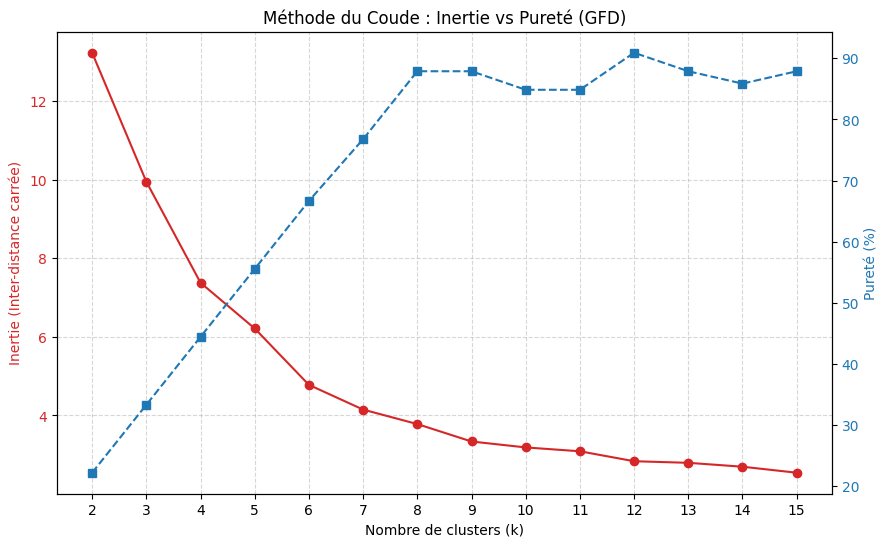

In [34]:
import matplotlib.pyplot as plt
import numpy as np
from utils import charger_donnees
# On importe tes fonctions depuis le fichier que tu as sauvegardé
#from kmeans_algo import kmeans, evaluer_clustering

# Configuration
base_folder = "C:/Users/lakaf/OneDrive/Bureau/25-26/RF/Projet_RF/data"
data = charger_donnees(base_folder)

# Préparation des données (GFD uniquement)
X = [d["GFD"] for d in data.values() if "GFD" in d]
X = np.array(X)
y_true = [d["class"] for d in data.values() if "GFD" in d]
y_true = np.array(y_true)

k_values = range(2, 16)
inertias = []
purities = []

print("Calcul de la méthode du coude...")
for k in k_values:
    # On utilise tes fonctions
    _, _, inertia = kmeans(X, k, max_iter=100, init='kmeans++', n_init=5)
    
    # On relance pour avoir la pureté moyenne (optionnel mais instructif)
    y_pred, _, _ = kmeans(X, k, max_iter=100, init='kmeans++', n_init=5)
    purity, _ = evaluer_clustering(y_true, y_pred)
    
    inertias.append(inertia)
    purities.append(purity * 100)
    print(f"k={k} traité.")

# Création du graphique à double axe
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:red'
ax1.set_xlabel('Nombre de clusters (k)')
ax1.set_ylabel('Inertie (Inter-distance carrée)', color=color)
ax1.plot(k_values, inertias, marker='o', color=color, label='Inertie')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.5)

# Axe secondaire pour la pureté
ax2 = ax1.twinx() 
color = 'tab:blue'
ax2.set_ylabel('Pureté (%)', color=color)
ax2.plot(k_values, purities, marker='s', linestyle='--', color=color, label='Pureté')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Méthode du Coude : Inertie vs Pureté (GFD)')
plt.xticks(k_values)
plt.show()

$Graphique~2~:~Matrice~de~Confusion~(Clusters~vs~Classes)$

Lecture terminée.
Nombre total d'images : 99
Exécution du K-Means (k=9)...


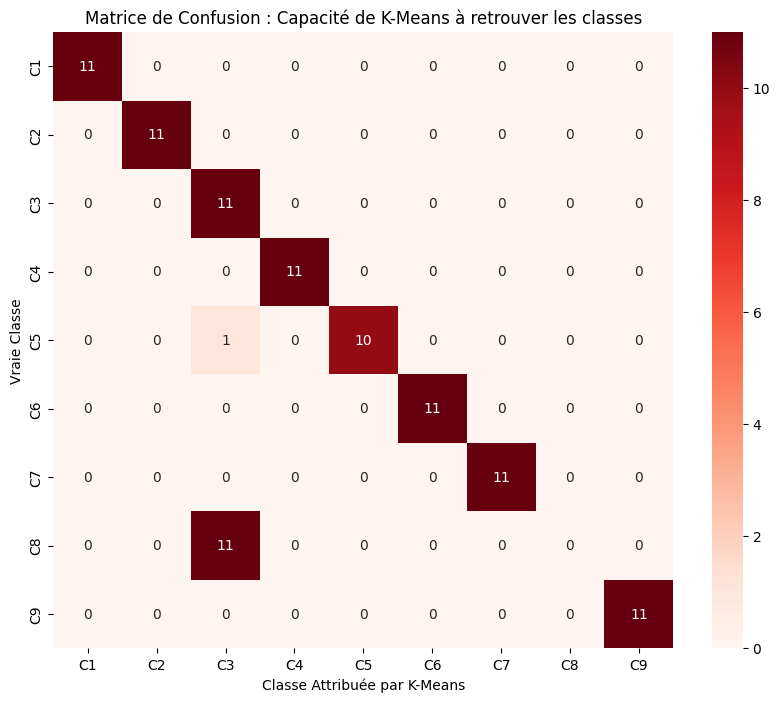

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from utils import charger_donnees

base_folder = "C:/Users/lakaf/OneDrive/Bureau/25-26/RF/Projet_RF/data"
data = charger_donnees(base_folder)

# Préparation
X = np.array([d["GFD"] for d in data.values() if "GFD" in d])
y_true = np.array([d["class"] for d in data.values() if "GFD" in d])

# Exécution avec le nombre théorique de classes (k=9)
print("Exécution du K-Means (k=9)...")
y_pred, _, _ = kmeans(X, k=9, max_iter=100, init='kmeans++', n_init=20)

# Mapping intelligent pour aligner les couleurs de la matrice
y_mapped, mapping = mapper_clusters_vers_classes(y_pred, y_true)

# Calcul matrice confusion manuelle (car celle de utils est pour le supervisé parfois)
confusion = np.zeros((9, 9), dtype=int)
for t, p in zip(y_true, y_mapped):
    confusion[t-1, p-1] += 1 # -1 car classes commencent à 1

plt.figure(figsize=(10, 8))
sns.heatmap(confusion, annot=True, fmt='d', cmap='Reds',
            xticklabels=[f"C{i}" for i in range(1, 10)],
            yticklabels=[f"C{i}" for i in range(1, 10)])

plt.xlabel('Classe Attribuée par K-Means')
plt.ylabel('Vraie Classe')
plt.title('Matrice de Confusion : Capacité de K-Means à retrouver les classes')
plt.show()

$Graphique~3~:~Stabilité~de~l'algorithme~(Boxplot)$

Lecture terminée.
Nombre total d'images : 99
Test de stabilité sur 20 exécutions...


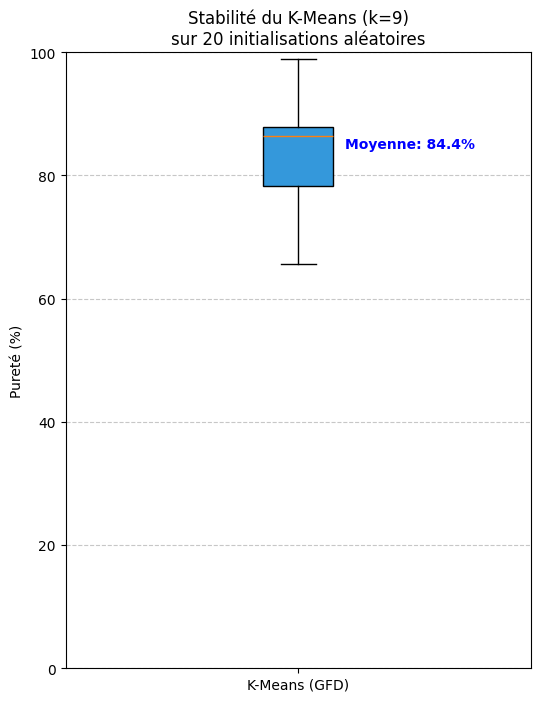

In [59]:
import matplotlib.pyplot as plt
import numpy as np
from utils import charger_donnees

base_folder = "C:/Users/lakaf/OneDrive/Bureau/25-26/RF/Projet_RF/data"
data = charger_donnees(base_folder)

X = np.array([d["GFD"] for d in data.values() if "GFD" in d])
y_true = np.array([d["class"] for d in data.values() if "GFD" in d])

n_runs = 20
purities = []

print(f"Test de stabilité sur {n_runs} exécutions...")
for i in range(n_runs):
    # n_init=1 pour voir la variance de l'initialisation pure
    y_pred, _, _ = kmeans(X, k=9, max_iter=100, init='random', n_init=1) #par defaut k=9
    purity, _ = evaluer_clustering(y_true, y_pred)
    purities.append(purity * 100)

plt.figure(figsize=(6, 8))
plt.boxplot(purities, patch_artist=True, boxprops=dict(facecolor="#3498db"))
plt.ylabel('Pureté (%)')
plt.title(f'Stabilité du K-Means (k=9)\nsur {n_runs} initialisations aléatoires')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

# Afficher la moyenne
plt.text(1.1, np.mean(purities), f'Moyenne: {np.mean(purities):.1f}%', 
         color='blue', fontweight='bold')

plt.xticks([1], ['K-Means (GFD)'])
plt.ylim(0, 100)
plt.show()

$Graphique~4~:~Équilibre~des~Clusters~(Histogramme)$

Lecture terminée.
Nombre total d'images : 99


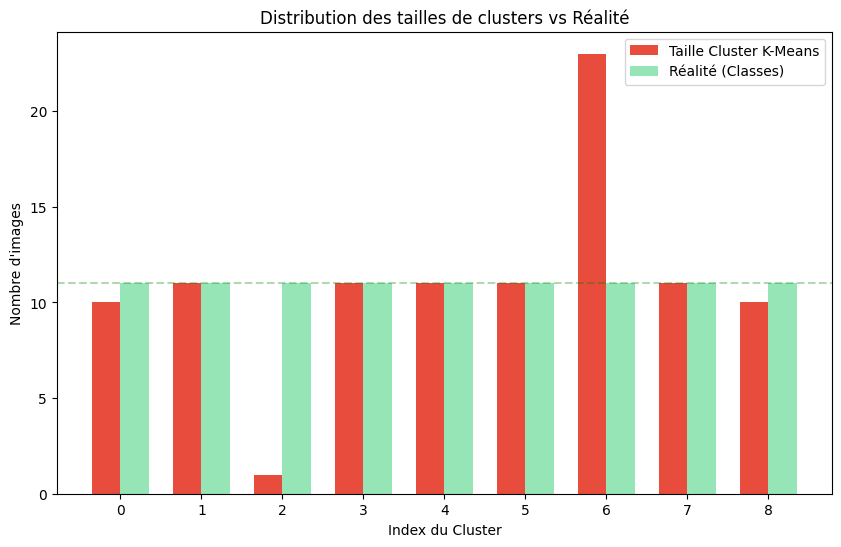

In [52]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from utils import charger_donnees

base_folder = "C:/Users/lakaf/OneDrive/Bureau/25-26/RF/Projet_RF/data"
data = charger_donnees(base_folder)

X = np.array([d["GFD"] for d in data.values() if "GFD" in d])
k = 9

# On lance K-Means
y_pred, _, _ = kmeans(X, k, max_iter=100, init='kmeans++', n_init=10)

# Comptage
counts = Counter(y_pred)
cluster_sizes = [counts[i] for i in range(k)]

# Attendu (11 images par classe pour 9 classes)
expected = [11] * k

x = np.arange(k)
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, cluster_sizes, width, label='Taille Cluster K-Means', color='#e74c3c')
plt.bar(x + width/2, expected, width, label='Réalité (Classes)', color='#2ecc71', alpha=0.5)

plt.xlabel('Index du Cluster')
plt.ylabel("Nombre d'images")
plt.title('Distribution des tailles de clusters vs Réalité')
plt.xticks(x)
plt.legend()
plt.axhline(y=11, color='green', linestyle='--', alpha=0.3)
plt.show()

**Supposément illogique comme resultat donc peut etre faux ?**

$Graphique~5~:~Comparaison~KNN~vs~K-Means$

Lecture terminée.
Nombre total d'images : 99
Calcul K-Means...


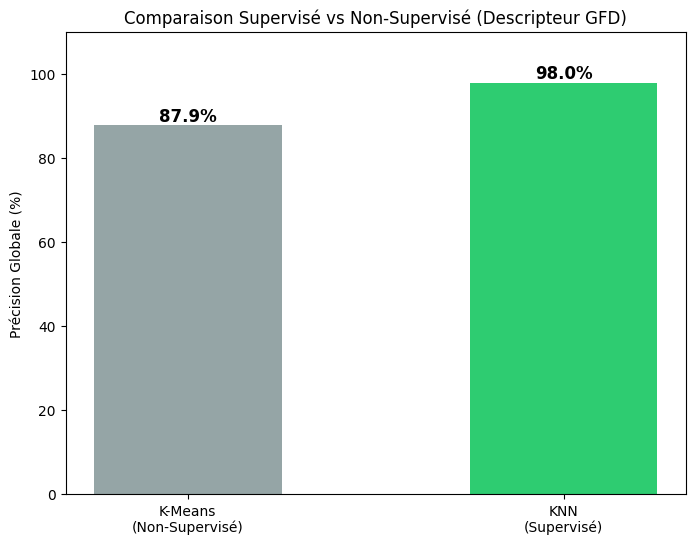

In [60]:
import matplotlib.pyplot as plt
import numpy as np
from utils import charger_donnees

base_folder = "C:/Users/lakaf/OneDrive/Bureau/25-26/RF/Projet_RF/data"
data = charger_donnees(base_folder)

X = np.array([d["GFD"] for d in data.values() if "GFD" in d])
y_true = np.array([d["class"] for d in data.values() if "GFD" in d])

# Calcul de la performance K-Means (Meilleur cas)
print("Calcul K-Means...")
y_pred, _, _ = kmeans(X, k=9, max_iter=100, init='kmeans++', n_init=20)
y_mapped, _ = mapper_clusters_vers_classes(y_pred, y_true)
acc_kmeans = np.sum(y_mapped == y_true) / len(y_true) * 100

# Performance KNN (Hardcodée depuis tes résultats précédents ou le texte)
acc_knn = 98.0  # Valeur issue de ton texte "KNN supervisé (98% avec GFD)"

methodes = ['K-Means\n(Non-Supervisé)', 'KNN\n(Supervisé)']
scores = [acc_kmeans, acc_knn]
colors = ['#95a5a6', '#2ecc71'] # Gris (bof) vs Vert (bon)

plt.figure(figsize=(8, 6))
bars = plt.bar(methodes, scores, color=colors, width=0.5)

plt.ylabel('Précision Globale (%)')
plt.title('Comparaison Supervisé vs Non-Supervisé (Descripteur GFD)')
plt.ylim(0, 110)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.show()